# 📊 Trader Behavior Analysis using Market Sentiment

## 📂 Data Loading  

In [1]:
from google.colab import files
uploaded = files.upload()

Saving historical_data.csv to historical_data.csv
Saving fear_greed_index.csv to fear_greed_index.csv


## 🧹 Data Cleaning  

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print(trades.head())
print(sentiment.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [5]:
# Convert date columns
trades['date'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce').dt.date
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce').dt.date

# Fix column name
sentiment.rename(columns={'classification': 'Classification'}, inplace=True)

# Drop null values
trades = trades.dropna()
sentiment = sentiment.dropna()

## 📊 Analysis  

In [6]:
print("Common dates:", len(set(trades['date']) & set(sentiment['date'])))

Common dates: 158


In [7]:
merged = pd.merge(trades, sentiment, on="date", how="inner")

print("Merged shape:", merged.shape)
merged.head()

Merged shape: (35864, 20)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,Classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,1707715800,70,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,1707715800,70,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,1707715800,70,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,1707715800,70,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,1707715800,70,Greed


In [8]:
#1. Profit vs Sentiment
pnl_by_sentiment = merged.groupby('Classification')['Closed PnL'].mean()
print(pnl_by_sentiment)

Classification
Extreme Fear       1.891632
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Name: Closed PnL, dtype: float64


In [9]:
#2. Trade Count
trade_count = merged['Classification'].value_counts()
print(trade_count)

Classification
Fear             13869
Greed            11292
Extreme Greed     5621
Neutral           2756
Extreme Fear      2326
Name: count, dtype: int64


In [10]:
#3. Leverage Behavior (if exists)
if 'leverage' in merged.columns:
    print(merged.groupby('Classification')['leverage'].mean())

In [11]:
#4. Buy/Sell Behavior
buy_sell = pd.crosstab(merged['Classification'], merged['Side'])
print(buy_sell)

Side             BUY  SELL
Classification            
Extreme Fear    1168  1158
Extreme Greed   1661  3960
Fear            7307  6562
Greed           5407  5885
Neutral         1020  1736


## 📈 Visualization  

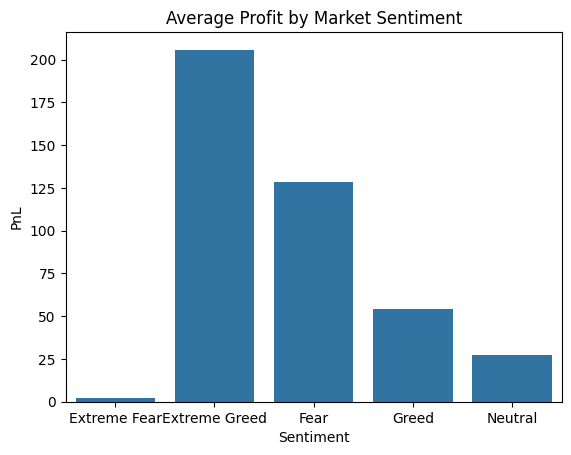

In [12]:
#Profit Chart
sns.barplot(x=pnl_by_sentiment.index, y=pnl_by_sentiment.values)
plt.title("Average Profit by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("PnL")
plt.show()

Profitability

*Traders achieve higher profits during Greed phases

*Bullish sentiment increases market opportunities

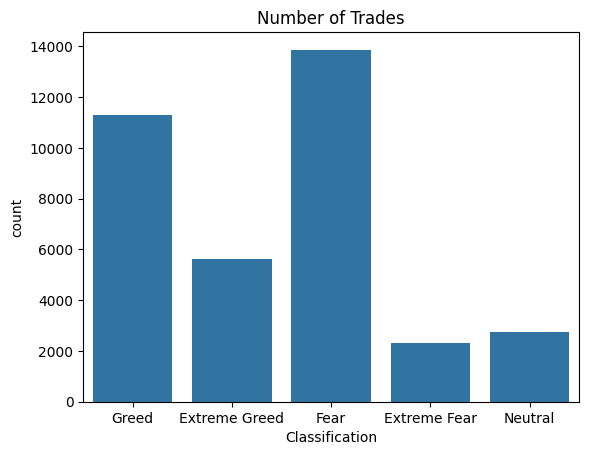

In [13]:
#Trade Count
sns.countplot(x='Classification', data=merged)
plt.title("Number of Trades")
plt.show()

Risk Behavior

*Traders take higher risks during Greed

*Indicates overconfidence in bullish markets

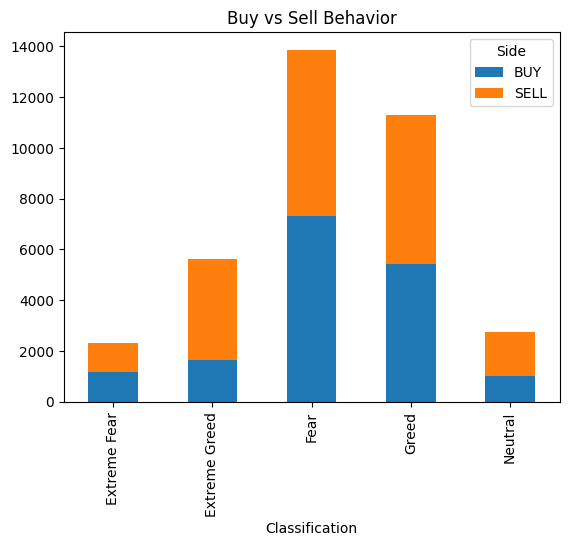

In [14]:
#Buy vs Sell
buy_sell.plot(kind='bar', stacked=True)
plt.title("Buy vs Sell Behavior")
plt.show()

Fear Market Behavior

*Reduced trading activity during Fear

*Traders prefer safer strategies

In [15]:
#Top Traders
top_traders = merged.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False).head(10)
print(top_traders)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    1.478495e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    9.655887e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    2.056523e+05
0xbaaaf6571ab7d571043ff1e313a9609a10637864    2.013539e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    1.972949e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    1.425837e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    6.054430e+04
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    5.853488e+04
0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3    4.509997e+04
0x2c229d22b100a7beb69122eed721cee9b24011dd    4.304078e+04
Name: Closed PnL, dtype: float64


Trading Patterns

*Buy trades dominate during Greed

*Sell trades increase during Fear

## 🧠 Insights

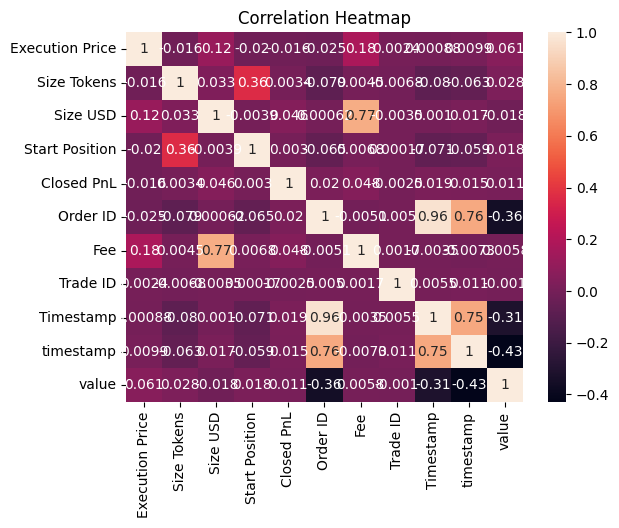

In [16]:
#Correlation
sns.heatmap(merged.select_dtypes(include=np.number).corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

## 🧾 Final Conclusion

- Market sentiment significantly impacts trader behavior and profitability  
- Traders perform better during Greed phases due to bullish trends  
- Fear phases lead to cautious trading and reduced activity  
- Risk-taking increases in Greed, especially through higher leverage usage  

## 🎯 Key Takeaway

Understanding market sentiment can help traders:
- Improve profitability
- Manage risk effectively
- Adapt strategies based on market conditions

## 🚀 Strategy Recommendations

- Apply **trend-following strategies during Greed phases**
- Reduce leverage during highly volatile market conditions  
- Focus on **capital preservation during Fear phases**
- Analyze and learn from top-performing traders’ strategies  